In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# from tensorflow.keras.utils import to_categorical # No longer needed for CrossEntropyLoss
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os
from tqdm import tqdm # Optional: for progress bars
import joblib

# --- 설정값 ---
INPUT_CSV_PATH = "normalized_fall_dataset.csv"  # 생성된 CSV 파일 경로
NUM_FRAMES = 10
NUM_LANDMARKS = 33
NUM_COORDS = 3
FEATURES_PER_FRAME = NUM_LANDMARKS * NUM_COORDS # 99
TOTAL_FEATURES = NUM_FRAMES * FEATURES_PER_FRAME # 990

# 하이퍼파라미터
HIDDEN_SIZE = 64  # LSTM 유닛 수 (Keras의 units)
NUM_LAYERS = 2    # LSTM 레이어 수 (단일 레이어 LSTM)
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
PATIENCE = 10 # Early stopping patience
MODEL_SAVE_PATH = "spline_best_lstm_model2.pth" # PyTorch 모델 저장 경로
SCALER_SAVE_PATH = "spline_scaler2.joblib"  # 스케일러 저장 경로
ENCODER_SAVE_PATH = "spline_label_encoder2.joblib"  # 인코더 저장 경로

# --- 0. 장치 설정 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- 1. 데이터 로드 및 준비 ---
print(f"🔄 '{INPUT_CSV_PATH}' 파일 로딩 중...")
try:
    df = pd.read_csv(INPUT_CSV_PATH)
    print(f"✅ 파일 로드 완료. Shape: {df.shape}")
except FileNotFoundError:
    print(f"❌ 에러: '{INPUT_CSV_PATH}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")
    exit()
except Exception as e:
    print(f"❌ 에러: CSV 파일 로딩 중 오류 발생 - {e}")
    exit()

# 레이블 및 특징 분리
if 'seq_name' not in df.columns or 'label' not in df.columns:
    print("❌ 에러: 입력 CSV에 'seq_name' 또는 'label' 컬럼이 없습니다.")
    exit()

labels_raw = df['label'].values
feature_columns = [col for col in df.columns if col not in ['seq_name', 'label']]

if len(feature_columns) != TOTAL_FEATURES:
     print(f"❌ 에러: Feature 컬럼 수가 {TOTAL_FEATURES}개가 아닙니다 ({len(feature_columns)}개 발견).")
     exit()

features_flat = df[feature_columns].values # (N, 990)

# 레이블 인코딩 (문자열 -> 정수) - CrossEntropyLoss는 정수 레이블 사용
label_encoder = LabelEncoder()
labels_int = label_encoder.fit_transform(labels_raw)
num_classes = len(np.unique(labels_int))
print(f"✅ 레이블 인코딩 완료. 클래스: {label_encoder.classes_} ({num_classes}개)")

# ===> LabelEncoder 저장 <===
try:
    joblib.dump(label_encoder, ENCODER_SAVE_PATH)
    print(f"✅ LabelEncoder 저장 완료: {ENCODER_SAVE_PATH}")
except Exception as e:
    print(f"❌ 에러: LabelEncoder 저장 중 오류 발생 - {e}")

# 특징 데이터 3D 형태로 변환: (N, 990) -> (N, 10, 99)
num_sequences = features_flat.shape[0]
X_sequences = features_flat.reshape(num_sequences, NUM_FRAMES, FEATURES_PER_FRAME)
print(f"✅ 특징 데이터 3D 변환 완료: {X_sequences.shape}")

# 훈련/검증 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_sequences, labels_int, # 정수 레이블 사용
    test_size=0.2,
    random_state=42,
    stratify=labels_int # 클래스 비율 유지
)
print(f"✅ 데이터 분리 완료:")
print(f"  훈련 데이터: X={X_train.shape}, y={y_train.shape}")
print(f"  검증 데이터: X={X_val.shape}, y={y_val.shape}")

# 특징 스케일링 (StandardScaler) - 중요!
# 3D -> 2D 변환 -> 스케일링 -> 3D 복원 (스케일링은 NumPy 배열 상태에서 수행)
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, FEATURES_PER_FRAME)
scaler.fit(X_train_flat)

# ===> StandardScaler 저장 <===
try:
    joblib.dump(scaler, SCALER_SAVE_PATH)
    print(f"✅ StandardScaler 저장 완료: {SCALER_SAVE_PATH}")
except Exception as e:
    print(f"❌ 에러: StandardScaler 저장 중 오류 발생 - {e}")

X_train_scaled_flat = scaler.transform(X_train_flat)
X_val_flat = X_val.reshape(-1, FEATURES_PER_FRAME)
X_val_scaled_flat = scaler.transform(X_val_flat)

# 다시 3D 형태로 복원
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape[0], NUM_FRAMES, FEATURES_PER_FRAME)
X_val_scaled = X_val_scaled_flat.reshape(X_val.shape[0], NUM_FRAMES, FEATURES_PER_FRAME)
print(f"✅ 특징 스케일링 완료 (StandardScaler 사용)")

# PyTorch Tensor로 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) # CrossEntropyLoss는 long 타입 레이블 요구
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Dataset 및 DataLoader 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("✅ PyTorch DataLoader 생성 완료")

🔄 'updated_fall_dataset.csv' 파일 로딩 중...
✅ 파일 로드 완료. Shape: (15443, 992)
✅ 레이블 인코딩 완료. 클래스: ['BY' 'FY' 'N' 'SY'] (4개)
✅ LabelEncoder 저장 완료: spline_label_encoder2.joblib
✅ 특징 데이터 3D 변환 완료: (15443, 10, 99)
✅ 데이터 분리 완료:
  훈련 데이터: X=(12354, 10, 99), y=(12354,)
  검증 데이터: X=(3089, 10, 99), y=(3089,)
✅ StandardScaler 저장 완료: spline_scaler2.joblib
✅ 특징 스케일링 완료 (StandardScaler 사용)
✅ PyTorch DataLoader 생성 완료


In [ ]:
class FallDetectionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_rate, bidirectional=True):
        super(FallDetectionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, # 입력: (batch, seq_len, feature)
                            dropout=dropout_rate if num_layers > 1 else 0, # 마지막 레이어 제외하고 드롭아웃 적용
                            bidirectional=bidirectional)

        self.dropout = nn.Dropout(dropout_rate)
        # BiLSTM 경우 hidden_size * 2
        self.fc = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x):

        lstm_out, _ = self.lstm(x) # 초기 state 없으면 자동 0으로 처리됨

        # 마지막 시점의 hidden state 사용 대신, 모든 시점의 output 사용 시퀀스 마지막 스텝 활용
        # Many-to-one: 마지막 time step의 출력을 사용
        # out = lstm_out[:, -1, :]
        # 시퀀스 전체 output 평균내서 사용 (대안)
        # out = torch.mean(lstm_out, dim=1)

        # 여기서는 마지막 시점의 출력을 사용
        last_time_step_out = lstm_out[:, -1, :]

        out = self.dropout(last_time_step_out)
        out = self.fc(out) # 최종 출력 (Softmax 전 Logits)

        # Softmax를 통해 각 클래스에 대한 확률로 변환
        # out = torch.softmax(out, dim=1)
        return out

# 모델 인스턴스화
model = FallDetectionLSTM(
    input_size=FEATURES_PER_FRAME,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True # 양방향 LSTM 사용
).to(device)

print("✅ 모델 정의 완료")
print(model)

# --- 3. 손실 함수 및 옵티마이저 정의 ---
criterion = nn.CrossEntropyLoss() # Softmax 포함되어 있음
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("✅ 손실 함수 및 옵티마이저 정의 완료")

✅ 모델 정의 완료
FallDetectionLSTM(
  (lstm): LSTM(99, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)
✅ 손실 함수 및 옵티마이저 정의 완료


In [4]:
# --- 4. 모델 훈련 ---
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_accuracy = 0.0
epochs_no_improve = 0

print("\n🚀 모델 훈련 시작...")
for epoch in range(EPOCHS):
    model.train() # 훈련 모드 설정
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # tqdm 사용 시
    # train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    # for inputs, labels in train_pbar:

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # 옵티마이저 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 + 역전파 + 최적화
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 통계
        running_loss += loss.item() * inputs.size(0) # 배치 손실 합계
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # tqdm 사용 시 상태 업데이트
        # train_pbar.set_postfix({'loss': loss.item()})

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # 검증 단계
    model.eval() # 평가 모드 설정
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): # 그래디언트 계산 비활성화
        # val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        # for inputs, labels in val_pbar:
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            # val_pbar.set_postfix({'loss': loss.item()})

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # Model Checkpoint (Best validation accuracy)
    if epoch_val_acc > best_val_accuracy:
        print(f"  Validation accuracy improved ({best_val_accuracy:.4f} -> {epoch_val_acc:.4f}). Saving model...")
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        best_val_accuracy = epoch_val_acc
        epochs_no_improve = 0 # 개선되었으므로 카운터 리셋
    else:
        epochs_no_improve += 1

    # Early Stopping
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

print("✅ 모델 훈련 완료")


🚀 모델 훈련 시작...
Epoch [1/50] | Train Loss: 1.1823, Train Acc: 0.5501 | Val Loss: 1.1135, Val Acc: 0.6206
  Validation accuracy improved (0.0000 -> 0.6206). Saving model...
Epoch [2/50] | Train Loss: 1.0564, Train Acc: 0.6841 | Val Loss: 1.0324, Val Acc: 0.7093
  Validation accuracy improved (0.6206 -> 0.7093). Saving model...
Epoch [3/50] | Train Loss: 0.9967, Train Acc: 0.7467 | Val Loss: 1.0032, Val Acc: 0.7381
  Validation accuracy improved (0.7093 -> 0.7381). Saving model...
Epoch [4/50] | Train Loss: 0.9758, Train Acc: 0.7653 | Val Loss: 0.9837, Val Acc: 0.7523
  Validation accuracy improved (0.7381 -> 0.7523). Saving model...
Epoch [5/50] | Train Loss: 0.9647, Train Acc: 0.7751 | Val Loss: 0.9763, Val Acc: 0.7601
  Validation accuracy improved (0.7523 -> 0.7601). Saving model...
Epoch [6/50] | Train Loss: 0.9468, Train Acc: 0.7952 | Val Loss: 0.9447, Val Acc: 0.7957
  Validation accuracy improved (0.7601 -> 0.7957). Saving model...
Epoch [7/50] | Train Loss: 0.9316, Train Acc: 0.8

In [5]:
# --- 5. 모델 평가 (최적 모델 로드) ---
print("\n📊 저장된 최적 모델 로드 및 최종 평가 중...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval() # 평가 모드

final_val_loss = 0.0
final_correct_val = 0
final_total_val = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        final_val_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        final_total_val += labels.size(0)
        final_correct_val += (predicted == labels).sum().item()

final_avg_val_loss = final_val_loss / final_total_val
final_val_accuracy = final_correct_val / final_total_val

print(f"  최적 모델 검증 손실 (Loss): {final_avg_val_loss:.4f}")
print(f"  최적 모델 검증 정확도 (Accuracy): {final_val_accuracy:.4f}")


📊 저장된 최적 모델 로드 및 최종 평가 중...
  최적 모델 검증 손실 (Loss): 0.8802
  최적 모델 검증 정확도 (Accuracy): 0.8601


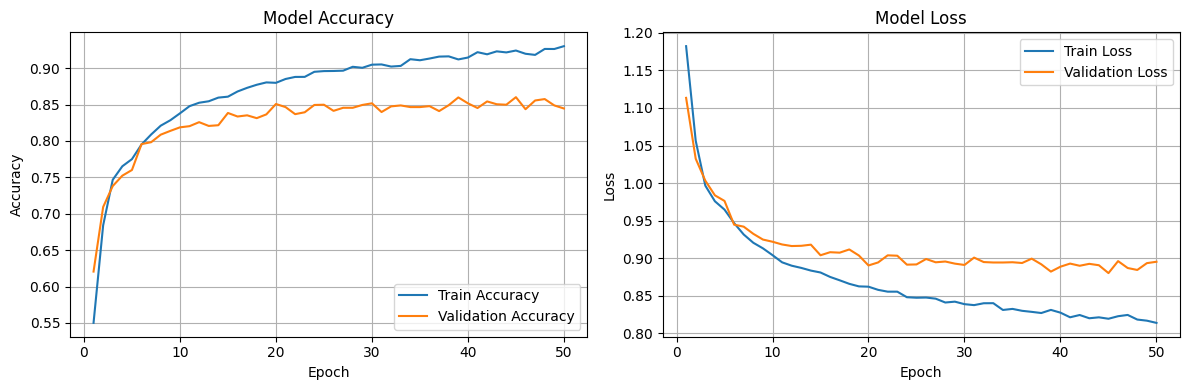


🎉 모든 과정 완료!


In [6]:
# --- 6. 학습 과정 시각화 ---
def plot_history(train_acc, val_acc, train_loss, val_loss):
    epochs_range = range(1, len(train_acc) + 1)
    plt.figure(figsize=(12, 4))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(train_accuracies, val_accuracies, train_losses, val_losses)

print("\n🎉 모든 과정 완료!")